## **Integrate the Ball**

## **Imports**

In [1]:
from bat_class import BatOsc, Ball, bat_from_json, ball_from_json
import numpy as np
import matplotlib.pyplot as plt
from plot_osc import plot_batsol_heatmap, plot_ball_collision_dynamics
import matplotlib.animation as animation
import json

## **Unit Functions**

In [2]:
def mps_to_mph(mps):
    """Converts m/s to miles per hour."""
    return mps * 2.23694

def m_to_inches(m):
    """Converts metres to inches"""
    return m * 39.37

def mph_to_mps(mph):
    """Converts miles per hour to m/s"""
    return mph / 2.24694

## **Load Bat and Ball**

In [3]:
# load standard bat
standard_bat = bat_from_json('data/bats/AdleyOld.json')
standard_bat.get_H_matrix()
standard_bat.set_initial_conditions(np.zeros(4*standard_bat.N))

#load ball
ball_key = 'squishy'
ball = ball_from_json(f'data/balls/{ball_key}_ball.json')

impact_idx = 76 #impact location index for standard bat

## **Bat Model Collision**

In [4]:
result = standard_bat.integrate_with_ball(t_span=(0, 0.01), ball=ball, t_eval=np.linspace(0, 0.01, 10000), impact_idx=impact_idx)

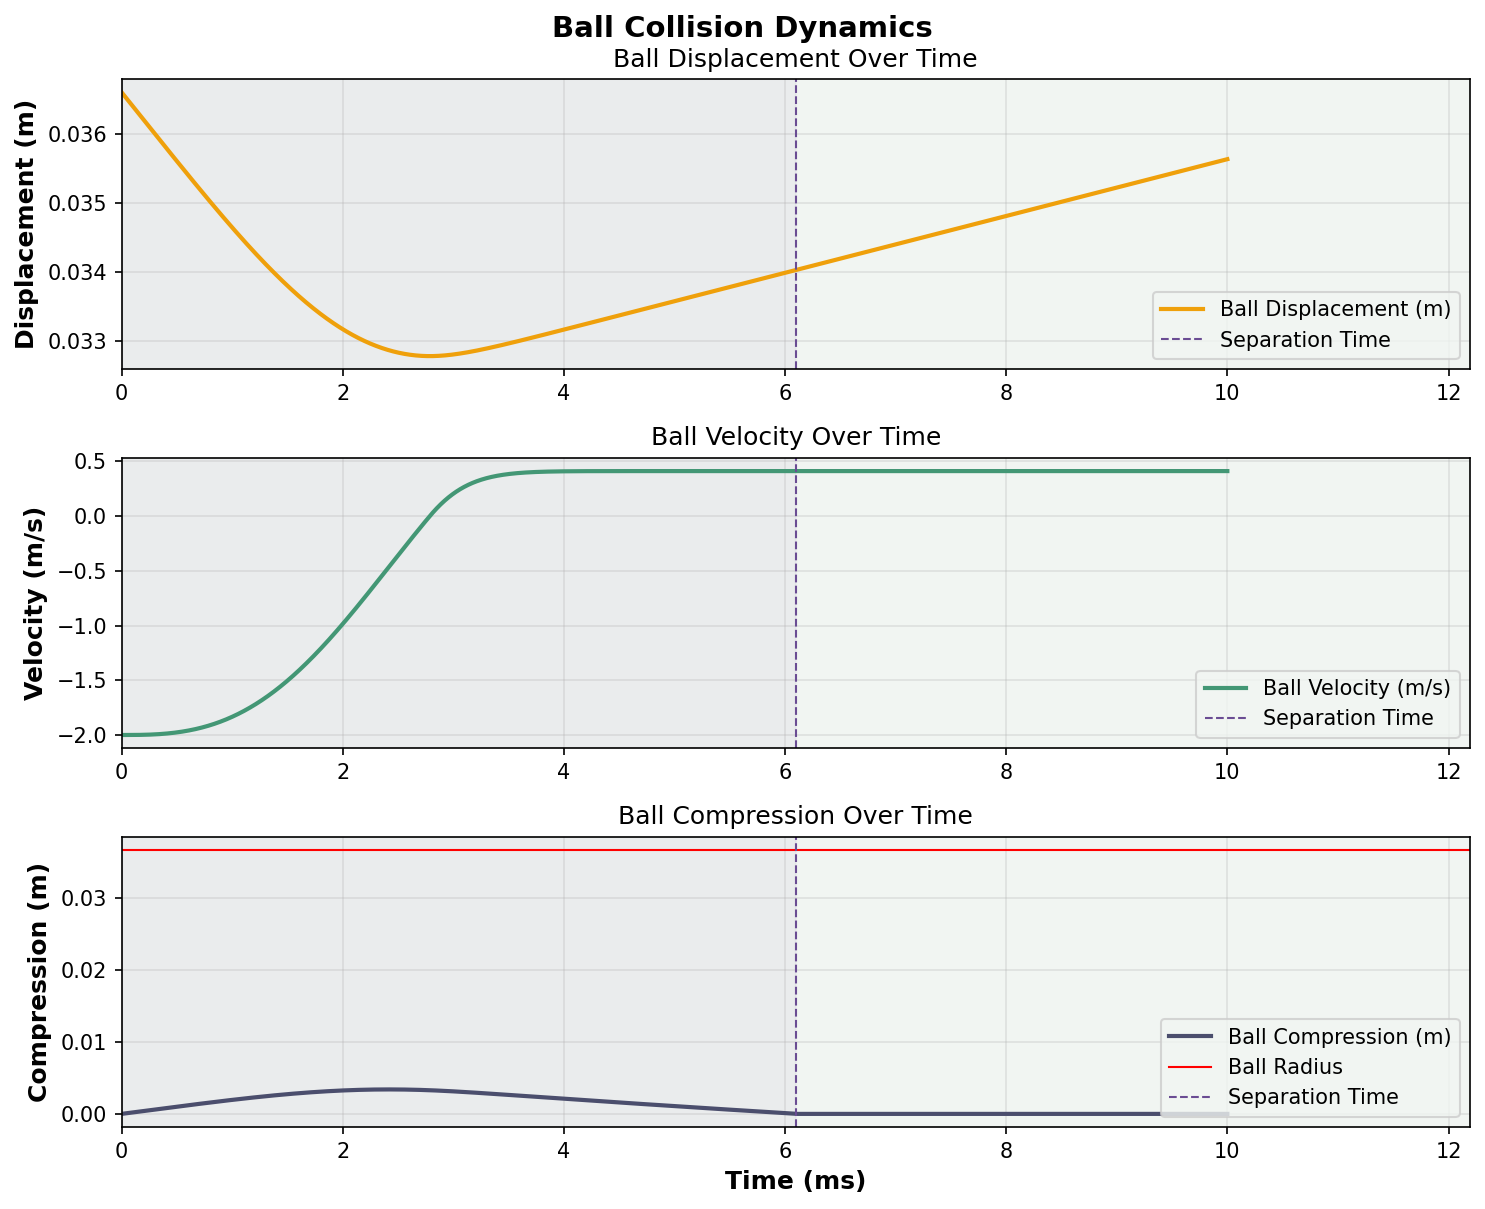

In [5]:
fig, ax = plot_ball_collision_dynamics(standard_bat.ball, title='Ball Collision Dynamics')

In [8]:
def get_ball_shape(compression, radius=ball.radius):
    """Returns the shape of the ball as an ellipse with semi-axes radius (x) and radius-compression (y)."""
    effective_y_radius = max(radius - compression, 0)
    theta = np.linspace(0, 2 * np.pi, 100)
    x = radius * np.cos(theta)
    y = effective_y_radius * np.sin(theta)
    return x, y

In [9]:
def animate_ball_compression(u, yb_sol, save_path='ball_compression.gif'):
    """Animate the ball compression during the collision."""
    fig, ax = plt.subplots(figsize=(6, 6))
    # ax.set_xlim(-Rb*2, Rb*2)
    # ax.set_ylim(-Rb*2, Rb*2)
    ax.set_aspect('equal')
    shape = ax.fill([], [], color='white')[0]
    outline = ax.plot([], [], color='black', linewidth=2)[0]
    centrepoint = ax.scatter([0], [0], color='red', s=20, zorder=5) # add a red dot at the center of the ball for reference

    def init():
        x = Rb * np.cos(np.linspace(0, 2 * np.pi, 100))
        y = Rb * np.sin(np.linspace(0, 2 * np.pi, 100))
        shape.set_xy(x, y)
        outline.set_data(x, y)
        centrepoint.set_offsets([(0, yb_sol[0])])
        return shape, outline, centrepoint,
    
    def update(frame):
        x, y = get_ball_shape(u[frame])
        shape.set_xy(np.column_stack([x, y]))
        outline.set_data(x, y)
        centrepoint.set_offsets([(0, 0)]) # keep the center point fixed at the origin since the ball is compressed symmetrically around its center
        ax.set_title(f'Time: {standard_bat.t[frame]*1e3:.2f} ms\nCompression: {u[frame]*1e3:.2f} mm', fontsize=12)
        return shape, outline, centrepoint,
    
    ani = animation.FuncAnimation(fig, update, frames=len(u), interval=2, repeat=False)
        # Save the animation as an mp4 file
    if save_path is not None:
        ani.save(save_path, writer='ffmpeg', dpi=150)

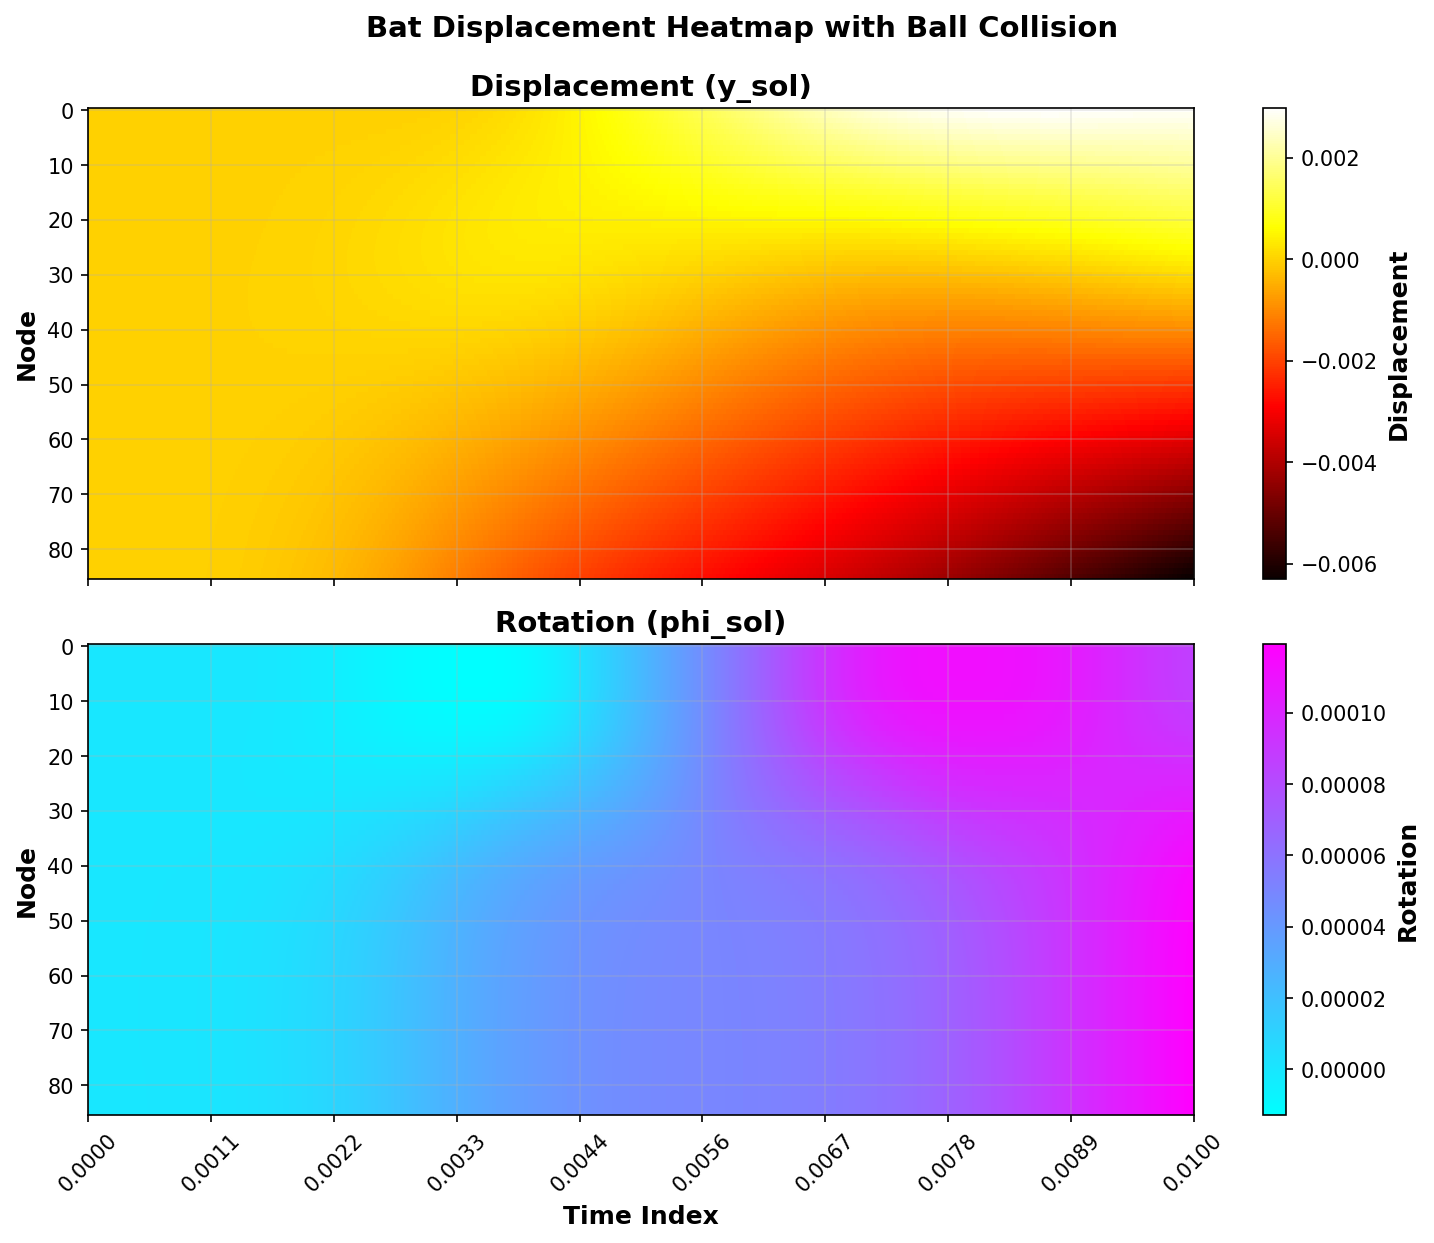

In [10]:
fig, ax = plot_batsol_heatmap(standard_bat)
fig.suptitle('Bat Displacement Heatmap with Ball Collision', fontsize=14, fontweight='bold', y = 1.03)
plt.show()

Now we will do a couple checks to make sure our ball results match up with theoretical expectations. The first is colliding the ball against a solid wall.

We expect for this collision $v_f/v_i = e_0$. 

## Wall Collision

In [11]:
## Solid Block Collision
wall_prof = np.array([[1, 0.5], [2, 0.5]]) # 2 slices with radius 0.5 m
wall = BatOsc(wall_prof, 1)
wall.set_bat_features(mass=1e20, rho=1e15, Y=1e20, S=1e20) # essentially a rigid wall with no deformation
wall.set_initial_conditions(np.zeros(4*wall.N)) # no initial displacement or velocity
wall.get_H_matrix()

In [12]:
#ball impact
ball.reset() # reset ball to initial conditions before integration
#integrate the system with the ball impact
result_block = wall.integrate_with_ball(t_span=(0, 0.01), ball=ball, t_eval=np.linspace(0, 0.01, 10000), impact_idx=0)

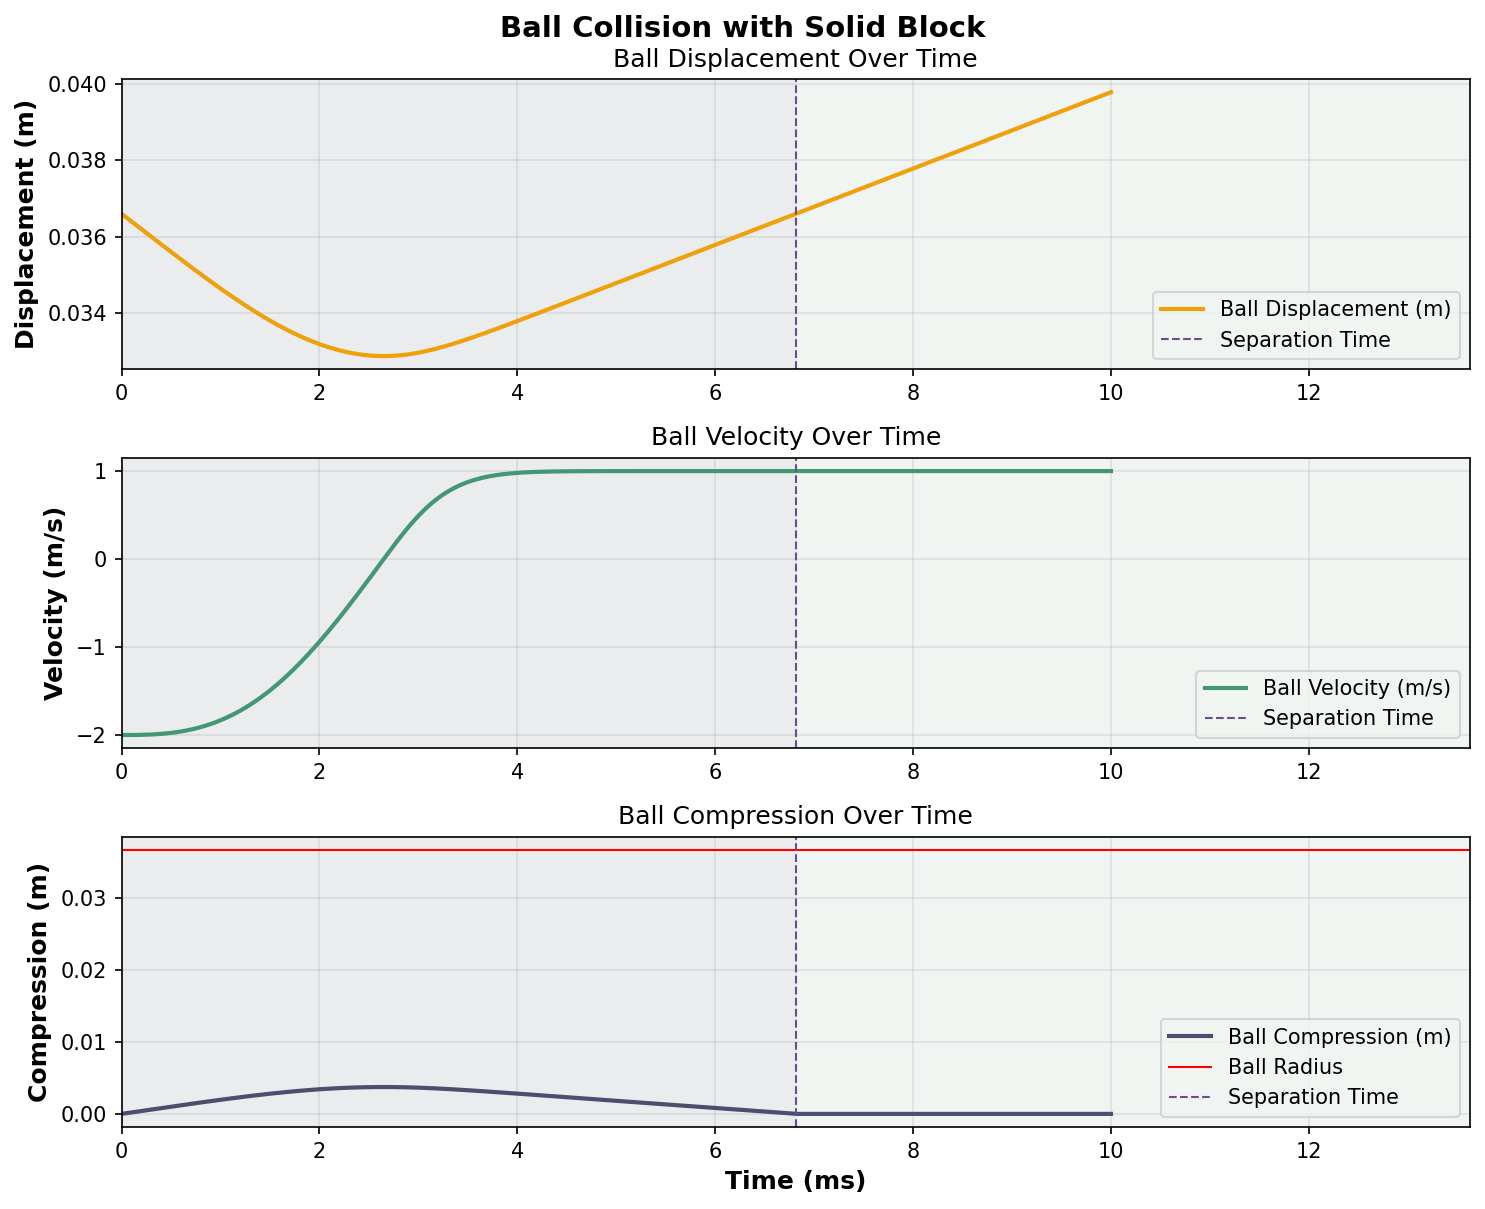

In [13]:
plot_ball_collision_dynamics(wall.ball, title='Ball Collision with Solid Block')
plt.show()

In [14]:
# vf / vi
final_velocity = wall.ball.yb_dot[-1]
velocity_ratio = final_velocity / ball.initial_velocity
print(f"Final velocity of the ball after collision: {final_velocity:.2f} m/s")
print(f"Velocity ratio (vf/vi): {velocity_ratio:.2f}")
print(f"Effective coefficient of restitution squared: {ball.e0}")

assert abs(velocity_ratio - ball.e0) < 1e-6, "Velocity ratio does not match expected coefficient of restitution squared"

Final velocity of the ball after collision: 1.00 m/s
Velocity ratio (vf/vi): 0.50
Effective coefficient of restitution squared: 0.5


Now, we collide the ball against a block of solid (but limited) mass. We expect

## Block Collision

In [15]:
## Solid Block Collision
N = 2 #number of slices in the wall
M = 400 # mass total
rho = M / (N * np.pi * 0.5**2) # density based on total mass and volume of the wall

block_prof = np.array([[1, 0.5], [2, 0.5]]) # 2 slices with radius 0.5 m
block = BatOsc(block_prof, 1)
block.set_bat_features(mass=M, rho=rho, Y=1e20, S=1e20) # essentially a rigid block with no deformation
block.set_initial_conditions(np.zeros(4*block.N)) # no initial displacement or velocity
block.get_H_matrix()

In [16]:
#ball impact
ball.reset() # reset ball to initial conditions before integration
#integrate the system with the ball impact
t_span = (0, 0.05)
t_eval = np.linspace(t_span[0], t_span[1], 10000)
result_block = block.integrate_with_ball(
    t_span=t_span,
    ball=ball,
    t_eval=t_eval,
    impact_idx=0,
    method='Radau',
    rtol=1e-7,
    atol=1e-9,
    max_step=1e-5,
    continue_free_vibration=False,
    verbose=True,
 )

Max compression at t = 2.651 ms: u_max = 3.727 mm, F_max = 220.9 N, k2 = 3.20e+27
Ball separates at t = 6.813 ms, ball exit v = 1.00 m/s


(<Figure size 1500x1350 with 3 Axes>,
 array([<Axes: title={'center': 'Ball Displacement Over Time'}, ylabel='Displacement (m)'>,
        <Axes: title={'center': 'Ball Velocity Over Time'}, ylabel='Velocity (m/s)'>,
        <Axes: title={'center': 'Ball Compression Over Time'}, xlabel='Time (ms)', ylabel='Compression (m)'>],
       dtype=object))

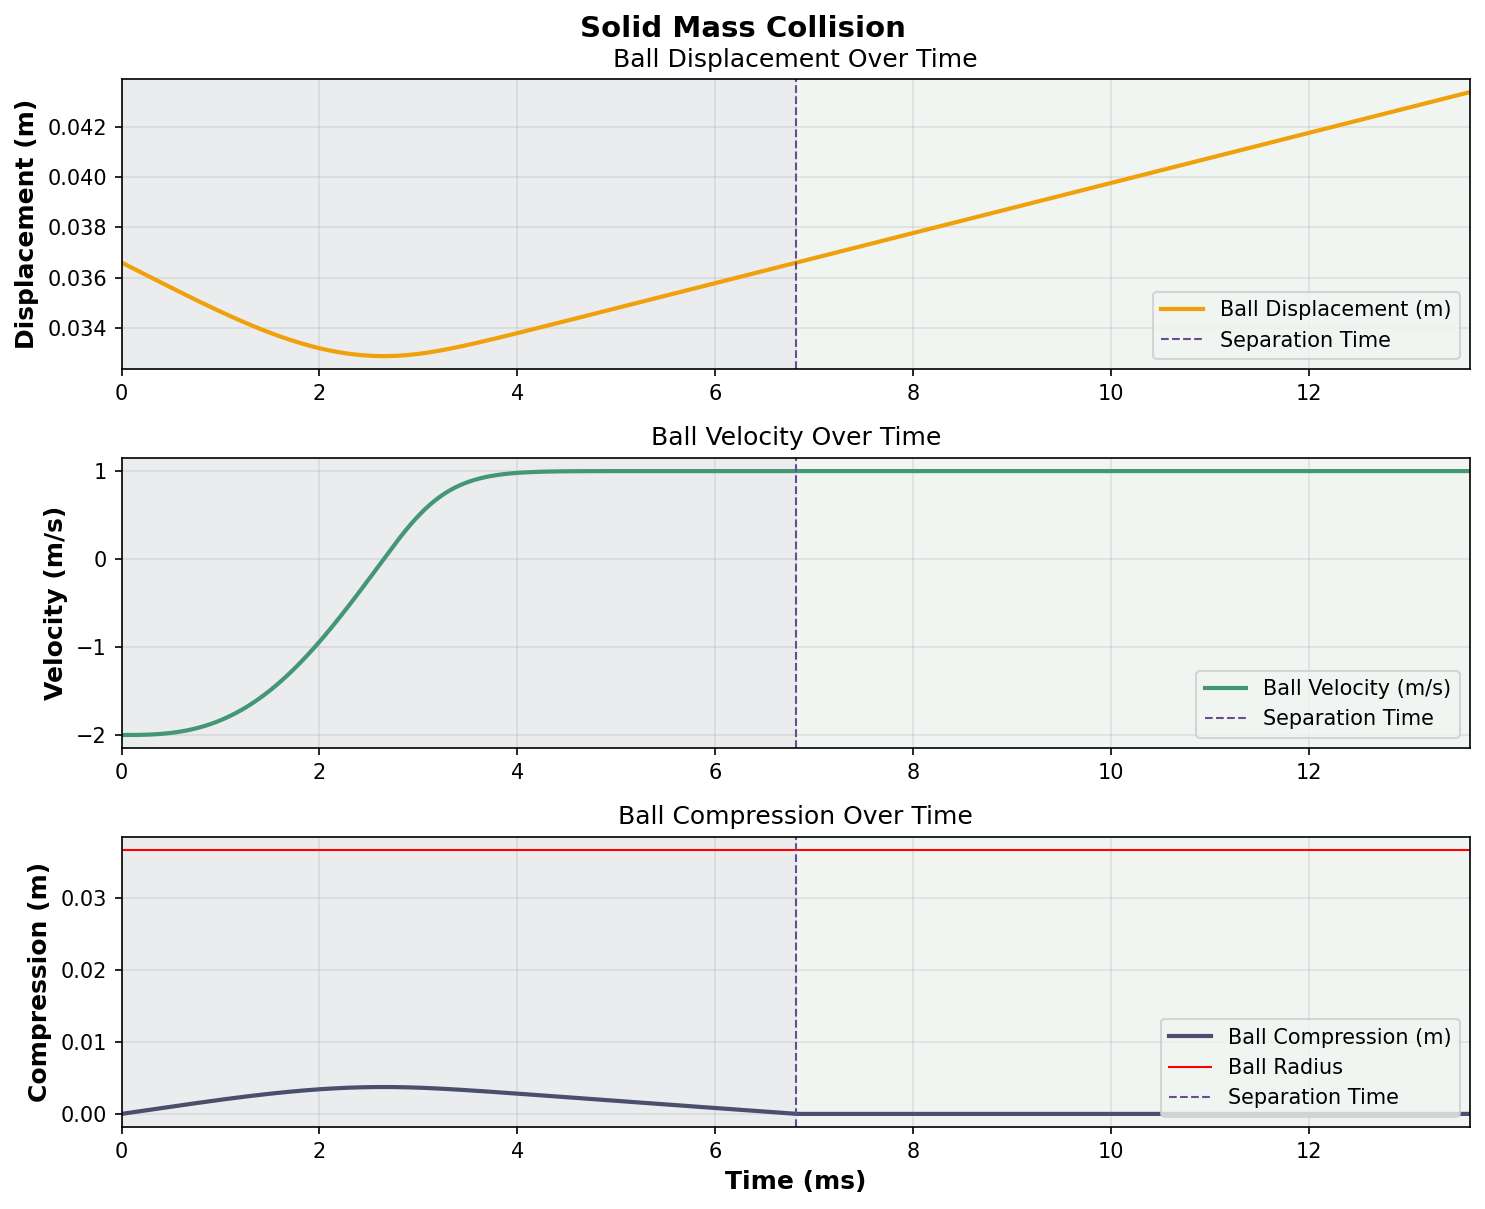

In [17]:
plot_ball_collision_dynamics(block.ball, title = 'Solid Mass Collision')

In [18]:
#(COR-m/M)/(1+m/M)
expected_v_ratio = (ball.e0 - ball.mass/block.mass) / (1 + ball.mass/block.mass)
final_velocity = block.ball.yb_dot[-1]
velocity_ratio = final_velocity / ball.initial_velocity
print(f"Final velocity of the ball after collision: {final_velocity:.2f} m/s")
print(f"Velocity ratio (vf/vi): {velocity_ratio:.4f}")
print(f"Expected velocity ratio from theory: {expected_v_ratio:.4f}")
print(f"Collision Time: {block.ball.t_separation:.6f} s")

assert abs(velocity_ratio - expected_v_ratio) < 1e-3, "Velocity ratio does not match expected theoretical value"

Final velocity of the ball after collision: 1.00 m/s
Velocity ratio (vf/vi): 0.4990
Expected velocity ratio from theory: 0.4995
Collision Time: 0.006813 s


In [19]:
print('Ball parameters:')
print(f"Mass: {block.ball.mass:.4f} kg")
print(f"Radius: {block.ball.radius:.4f} m")
print(f"Initial Velocity: {block.ball.initial_velocity:.2f} m/s = {mps_to_mph(block.ball.initial_velocity):.2f} mph")
print(f"k1 = {block.ball.k1:.2e} N/m^alpha")

Ball parameters:
Mass: 0.1450 kg
Radius: 0.0366 m
Initial Velocity: 2.00 m/s = 4.47 mph
k1 = 6.50e+06 N/m^alpha


## Rigid Bat

Last test: rigid bat

In [ ]:
#load json
with open('data/bats/standard_bat_params.json', 'r') as f:
    bat_params = json.load(f)

bat_prof = np.loadtxt(bat_params['profile_file'])
bat_prof[:, 0] *= 1e-2 # convert from cm to m
bat_prof[:, 1] *= 1e-3/2 # convert from cm to m


#normal bat but much more stiff
rigid_bat = BatOsc(bat_prof, bat_params['dz'])
rigid_bat.set_bat_features(mass=bat_params['mass'], rho=bat_params['rho'], Y=1e20, S=1e20)
rigid_bat.get_H_matrix()

In [20]:
reload_bat = bat_from_json('data/bats/standard_bat_params.json')